<a href="https://colab.research.google.com/github/Nikralet/General/blob/main/5%2C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# ==================== БЛОК 1: ИМПОРТЫ И НАСТРОЙКИ ====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import eigh
from scipy import special
from scipy.special import gammaln
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft, fftfreq

from tqdm import tqdm # прогресс бар интегрирования

# Для анимации (если потребуется)
import matplotlib
from matplotlib.animation import FuncAnimation
matplotlib.rcParams['animation.embed_limit'] = 50.0
from IPython.display import HTML

print("Блок 1 завершён: импорты выполнены.")

Блок 1 завершён: импорты выполнены.


In [53]:
# ==================== БЛОК 2: ПАРАМЕТРЫ СИСТЕМЫ ====================
# Размер базиса для одного осциллятора (число фоковских состояний)
n = 50

# Число точек координатной сетки для визуализации
N_grid = 250

# Физические параметры (атомные единицы: hbar = 1, m = 1)
m = 1.0
hbar = 1.0

# Область интегрирования: выбираем достаточно большой интервал,
# чтобы захватить хвосты волновых функций (особенно для мягкой моды)
l = 4.0

# Частоты осцилляторов (можно менять)
omega1 = 1.0
omega2 = 2.0

# Коэффициент связи (линейная связь K * x1 * x2)
# Здесь K — безразмерный параметр, так как мы добавили множитель 1/√(ω1ω2)
K = 2.0

# Параметры внешней гармонической силы F * cos(Ω * t), действующей на осциллятор 1
F_drive = 0.2        # амплитуда силы
# Частоту Ω будем подбирать позже

# Параметр нелинейности (если нужен ангармонизм, но пока отключён)
koeff = hbar/(2*m*40)   # для совместимости, не используется при linearity="linear"

omegas = (omega1, omega2)
print("Блок 2 завершён: параметры заданы.")

Блок 2 завершён: параметры заданы.


In [54]:
# ==================== БЛОК 3: ОПЕРАТОРЫ РОЖДЕНИЯ И УНИЧТОЖЕНИЯ ====================
# Операторы уничтожения (a) и рождения (a†) для одного осциллятора
a = np.diag(np.sqrt(np.arange(1, n)), k=1)      # уничтожение
ad = np.diag(np.sqrt(np.arange(1, n)), k=-1)    # рождение

# Единичная матрица
I = np.eye(n)

# Оператор координаты (безразмерный): X = a + ad
# Физическая координата x = X / √(2ω) (будем использовать ниже с нужным ω)
X_op = a + ad

print("Блок 3 завершён: операторы a, ad, I, X_op созданы.")

Блок 3 завершён: операторы a, ad, I, X_op созданы.


In [55]:
# ==================== БЛОК 4: ГАМИЛЬТОНИАН ОДНОГО ОСЦИЛЛЯТОРА ====================
def hamiltonian_single(omega, nonlinear=False):
    """
    Гамильтониан одного гармонического осциллятора в фоковском базисе.
    nonlinear = True добавляет член k x^4 (с коэффициентом k = (koeff/omega)^2).
    """
    # Масштабированный оператор координаты
    x_phys = X_op / np.sqrt(2 * omega)

    # Гармоническая часть
    H0 = hbar * omega * (ad @ a + 0.5 * I)

    if not nonlinear:
        return H0
    else:
        # Ангармонический член: (koeff/omega)^2 * x^4
        # Здесь x^4 = (x_phys @ x_phys) @ (x_phys @ x_phys) — матричное умножение
        H_nonlin = (koeff/omega)**2 * (x_phys @ x_phys) @ (x_phys @ x_phys)
        return H0 + H_nonlin

print("Блок 4 завершён: функция гамильтониана одного осциллятора определена.")

Блок 4 завершён: функция гамильтониана одного осциллятора определена.


In [56]:
# ==================== БЛОК 5: ПОЛНЫЙ ГАМИЛЬТОНИАН ДВУХ ОСЦИЛЛЯТОРОВ ====================
def hamiltonian_coupled(omegas, K, nonlinear=False):
    """
    Полный гамильтониан двух связанных осцилляторов с линейной связью K * x1 * x2.
    Возвращает матрицу размера (n*n, n*n).
    """
    omega1, omega2 = omegas

    # Масштабированные операторы координат для каждого осциллятора
    x1_phys = X_op / np.sqrt(2 * omega1)
    x2_phys = X_op / np.sqrt(2 * omega2)

    # Гамильтонианы отдельных осцилляторов
    H1 = hamiltonian_single(omega1, nonlinear)
    H2 = hamiltonian_single(omega2, nonlinear)

    # Тензорные произведения для построения полного гамильтониана
    # H1 ⊗ I + I ⊗ H2 + K * (x1 ⊗ x2) с дополнительным множителем,
    # делающим K безразмерным: K_eff = K * (1/√(ω1ω2)) в атомных единицах.
    # Можно просто оставить K * kron(x1, x2), тогда K будет иметь размерность энергии.
    # Здесь оставим как в исходном коде: K * (m/√(ω1ω2)) * kron(x1, x2)
    H_interaction = K * (1.0 / np.sqrt(omega1 * omega2)) * np.kron(x1_phys, x2_phys)

    H_full = np.kron(H1, I) + np.kron(I, H2) + H_interaction

    # Выведем эффективный безразмерный параметр связи для справки
    print(f"Эффективная безразмерная связь: {K / np.sqrt(omega1 * omega2):.2f}")
    return H_full

# Построим гамильтониан
H_full = hamiltonian_coupled(omegas, K, nonlinear=True)
print(f"Размер полного гамильтониана: {H_full.shape}")
print("Блок 5 завершён.")

Эффективная безразмерная связь: 1.41
Размер полного гамильтониана: (2500, 2500)
Блок 5 завершён.


In [57]:
# ==================== БЛОК 6: ДИАГОНАЛИЗАЦИЯ (СТАЦИОНАРНАЯ ЗАДАЧА) ====================
# Диагонализуем гамильтониан
energies, U = eigh(H_full)   # U — матрица собственных векторов (столбцы), energies — собственные значения (энергии)

print(f"Первые 3 энергий: {energies[:3]}")
print(f"Норма первого собственного вектора: {np.sum(np.abs(U[:,0])**2):.2e}")

# Число состояний
print(f"Всего состояний: {len(energies)}")
print("Блок 6 завершён.")

Первые 3 энергий: [1.39919631 2.06219902 2.72599995]
Норма первого собственного вектора: 1.00e+00
Всего состояний: 2500
Блок 6 завершён.


In [58]:
# ==================== БЛОК 7: ПОСТРОЕНИЕ ОПЕРАТОРОВ КООРДИНАТ В СОБСТВЕННОМ БАЗИСЕ ====================
# Операторы координат в фоковском базисе (полные)
x1_full = np.kron(X_op / np.sqrt(2 * omega1), I)
x2_full = np.kron(I, X_op / np.sqrt(2 * omega2))

# Преобразование в собственный базис: U^T @ X_full @ U (U вещественная, ортогональная)
X1_eig = U.T @ x1_full @ U
X2_eig = U.T @ x2_full @ U

# Проверим диагональные элементы для нескольких состояний
print("Диагональные элементы X1_eig для первых 3 состояний:")
print(np.diag(X1_eig)[:3])
print("Диагональные элементы X2_eig для первых 3 состояний:")
print(np.diag(X2_eig)[:3])
print("Блок 7 завершён.")

Диагональные элементы X1_eig для первых 3 состояний:
[ 9.01346046e-18  1.91651932e-16 -2.87196428e-16]
Диагональные элементы X2_eig для первых 3 состояний:
[-1.35226020e-18 -1.12573853e-16  7.33554446e-17]
Блок 7 завершён.


In [59]:
# ==================== БЛОК 8: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ КООРДИНАТНОГО ПРЕДСТАВЛЕНИЯ ====================
def hermite_polynomial(n, x):
    """Полином Эрмита (из scipy)"""
    return special.hermite(n, monic=False)(x)

def harmonic_wf(n, x, omega, m=1.0, hbar=1.0):
    """
    Волновая функция гармонического осциллятора φ_n(x) для частоты omega.
    Возвращает массив значений на сетке x.
    """
    alpha = np.sqrt(m * omega / hbar)
    xi = alpha * x
    # Нормировка (логарифмическая для больших n)
    if n == 0:
        norm = (alpha / np.pi)**0.25
    else:
        log_norm = -0.5 * (n * np.log(2) + gammaln(n + 1)) + 0.5 * np.log(alpha / np.sqrt(np.pi))
        norm = np.exp(log_norm)
    return norm * hermite_polynomial(n, xi) * np.exp(-xi**2 / 2)

def fock_to_coordinate_2d(psi_fock, omegas, x_grid):
    """
    Преобразование набора состояний из фоковского базиса (векторы длины n^2)
    в координатное представление (значения на сетке x1, x2).
    psi_fock: массив (n^2, n_states) — столбцы коэффициенты.
    x_grid: одномерная сетка.
    Возвращает массив (n_states, nx, nx) волновых функций.
    """
    nx = len(x_grid)
    n_fock = int(np.sqrt(psi_fock.shape[0]))  # должно быть n
    n_states = psi_fock.shape[1]

    # Базисные функции для каждого осциллятора
    basis1 = np.zeros((nx, n_fock))
    basis2 = np.zeros((nx, n_fock))
    for ni in range(n_fock):
        basis1[:, ni] = harmonic_wf(ni, x_grid, omegas[0])
        basis2[:, ni] = harmonic_wf(ni, x_grid, omegas[1])

    psi_coord = np.zeros((n_states, nx, nx), dtype=complex)
    for k in range(n_states):
        coeff = psi_fock[:, k].reshape((n_fock, n_fock), order='C')
        psi_coord[k] = basis1 @ coeff @ basis2.T
    return psi_coord

# Создадим координатную сетку для визуализации
x_grid = np.linspace(-l, l, N_grid)

# Выберем несколько первых состояний и преобразуем их (для проверки нормировки)
n_states = len(energies)
n_show = min(3, n_states)
psi_coord = fock_to_coordinate_2d(U[:, :n_show], omegas, x_grid)

# Проверим нормировку (двойной интеграл)
dx = x_grid[1] - x_grid[0]
print("\nПроверка нормировки первых состояний:")
for i in range(n_show):
    norm = np.trapezoid(np.trapezoid(np.abs(psi_coord[i])**2, dx=dx, axis=1), dx=dx)
    print(f"Состояние {i}: ∫∫|ψ|² = {norm:.4f}")

print("Блок 8 завершён.")


Проверка нормировки первых состояний:
Состояние 0: ∫∫|ψ|² = 0.8477
Состояние 1: ∫∫|ψ|² = 0.8794
Состояние 2: ∫∫|ψ|² = 0.9021
Блок 8 завершён.


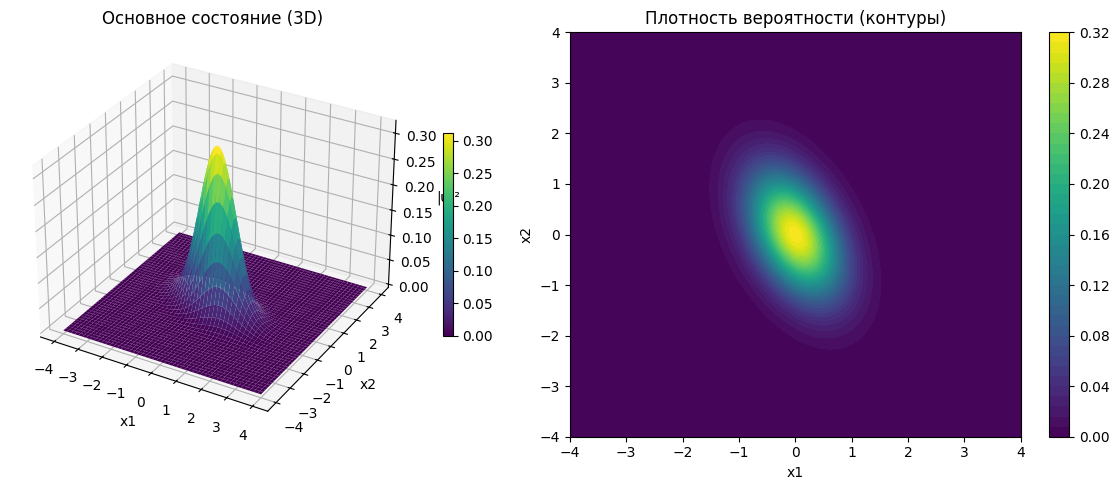

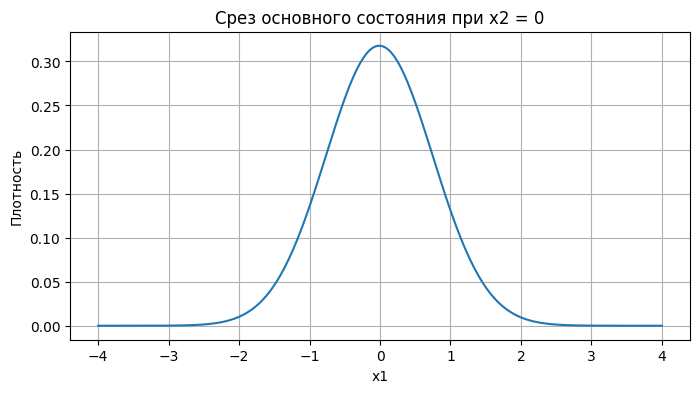

Блок 9 завершён.


In [60]:
# ==================== БЛОК 9: ВИЗУАЛИЗАЦИЯ ОСНОВНОГО СОСТОЯНИЯ ====================
# Основное состояние — индекс 0
psi0_2d = psi_coord[0]

# 3D поверхность
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
X1, X2 = np.meshgrid(x_grid, x_grid, indexing='ij')
surf = ax1.plot_surface(X1, X2, np.abs(psi0_2d)**2, cmap='viridis', linewidth=0, antialiased=True)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('|ψ|²')
ax1.set_title('Основное состояние (3D)')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Контурный график
ax2 = fig.add_subplot(122)
cont = ax2.contourf(x_grid, x_grid, np.abs(psi0_2d)**2, levels=50, cmap='viridis')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Плотность вероятности (контуры)')
plt.colorbar(cont, ax=ax2)

plt.tight_layout()
plt.show()

# Срез при x2 = 0
idx0 = np.argmin(np.abs(x_grid))
plt.figure(figsize=(8,4))
plt.plot(x_grid, np.abs(psi0_2d[:, idx0])**2, label='|ψ(x1,0)|²')
plt.xlabel('x1')
plt.ylabel('Плотность')
plt.title('Срез основного состояния при x2 = 0')
plt.grid()
plt.show()
print("Блок 9 завершён.")

**ВРЕМЕННАЯ ЭВОЛЮЦИЯ. ВРЕМЕННОЕ УРАВНЕНИЕ ШРЁДИНГЕРА**

In [ ]:
# ==================== БЛОК 10: ВРЕМЕННАЯ ЭВОЛЮЦИЯ (ОДНА ЧАСТОТА) ====================
# Выберем частоту внешней силы (можно менять)
Omega_drive = 1.3   # например

# Начальное состояние: основное состояние (индекс 0)
n_states = len(energies)
psi0 = np.zeros(n_states, dtype=complex)
psi0[0] = 1.0

# Оператор возбуждения: сила действует на первый осциллятор
drive_op = X1_eig   # можно также выбрать X2_eig для воздействия на второй

# Временной интервал и точки вывода
t_max = 10
t_eval = np.linspace(0, t_max, 50)

# Функция правой части уравнения Шрёдингера с обновлением прогресса
# Создаём прогресс-бар с обновлением не чаще 5 секунд
pbar = tqdm(total=t_max, desc="Интегрирование", unit="t",
            mininterval=5.0, bar_format='{l_bar}{bar}|')

last_t = 0
def schrodinger_eq(t, psi, E, drive_op, F, Omega):
    global last_t
    # Обновляем прогресс на пройденное время (с учётом mininterval)
    pbar.update(t - last_t)
    last_t = t
    H = np.diag(E) + F * np.cos(Omega * t) * drive_op
    return -1j * H @ psi

# Интегрируем
print(f"Запуск интегрирования для Ω = {Omega_drive:.3f}...")
sol = solve_ivp(schrodinger_eq, (0, t_max), psi0, t_eval=t_eval,
                args=(energies, drive_op, F_drive, Omega_drive),
                method='RK45', rtol=1e-8, atol=1e-10)
pbar.close()
print("Интегрирование завершено.")

# Извлекаем решение
psi_t = sol.y   # shape (n_states, len(t_eval))

# Вычисляем средние значения координат для каждого момента времени
x1_mean = np.zeros(len(t_eval), dtype=float)
x2_mean = np.zeros(len(t_eval), dtype=float)

for i, t in enumerate(t_eval):
    psi = psi_t[:, i]
    x1_mean[i] = np.real(np.conj(psi) @ X1_eig @ psi)
    x2_mean[i] = np.real(np.conj(psi) @ X2_eig @ psi)

# Визуализация
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(t_eval, x1_mean, label='<x1>')
plt.plot(t_eval, x2_mean, label='<x2>')
plt.xlabel('t')
plt.ylabel('Средняя координата')
plt.legend()
plt.title(f'Внешняя частота Ω = {Omega_drive:.3f}')

# Спектр Фурье для <x2> (установившийся режим)
# Возьмем последнюю треть временного интервала
n_late = len(t_eval) // 3
t_late = t_eval[-n_late:]
x2_late = x2_mean[-n_late:]
dt = t_eval[1] - t_eval[0]
freq = fftfreq(len(t_late), dt)
fft_vals = fft(x2_late - np.mean(x2_late))

plt.subplot(1,2,2)
plt.plot(freq[:len(freq)//2], np.abs(fft_vals[:len(freq)//2]))
plt.xlabel('Частота')
plt.ylabel('Амплитуда Фурье')
plt.title('Спектр <x2> (установившийся)')
plt.grid()
plt.tight_layout()
plt.show()

print("Блок 10 завершён.")

Интегрирование:   2%|▏         | 0.18343332869175205/10 [01:52<1:40:46, 615.98s/t]


Запуск интегрирования для Ω = 1.300...


Интегрирование:   8%|▊         | 8.1%

In [ ]:
# ==================== БЛОК 11: СКАНИРОВАНИЕ ПО ЧАСТОТАМ (ПОИСК АНТИРЕЗОНАНСА) ====================
# Внимание: этот блок может выполняться долго (около 5–10 минут при n=50 и 50 частотах).
# При необходимости уменьшите количество частот или используйте меньший n для теста.

# Диапазон частот для сканирования
Omega_list = np.linspace(0.5, 2.5, 10)
amp2_list = []

# Для ускорения можно уменьшить временной интервал и брать только установившийся режим
t_scan_start = 200
t_scan_end = 300
t_scan = np.linspace(t_scan_start, t_scan_end, 200)

print("Начинаем сканирование по частотам...")
for i, Omega in enumerate(Omega_list):
    print(f"Частота {i+1}/{len(Omega_list)}: {Omega:.3f}")
    sol = solve_ivp(schrodinger_eq, (t_scan_start, t_scan_end), psi0, t_eval=t_scan,
                    args=(energies, drive_op, F_drive, Omega),
                    method='RK45', rtol=1e-7, atol=1e-9)
    psi_t_scan = sol.y
    # Вычисляем средние для последнего момента (или среднюю амплитуду)
    x2_vals = []
    for j in range(psi_t_scan.shape[1]):
        psi = psi_t_scan[:, j]
        x2_vals.append(np.real(np.conj(psi) @ X2_eig @ psi))
    # Амплитуда как размах (max - min) или среднеквадратичное
    amp = np.max(x2_vals) - np.min(x2_vals)
    amp2_list.append(amp)

# Строим зависимость амплитуды от частоты
plt.figure(figsize=(10,6))
plt.plot(Omega_list, amp2_list, 'o-')
plt.xlabel('Частота внешней силы Ω')
plt.ylabel('Амплитуда колебаний <x2>')
plt.title('Отклик второго осциллятора')
plt.grid()
plt.show()

# Найдём частоты, где амплитуда минимальна
min_indices = np.argsort(amp2_list)[:3]  # три самых маленьких
print("Частоты с наименьшей амплитудой <x2>:")
for idx in min_indices:
    print(f"Ω = {Omega_list[idx]:.3f}, амплитуда = {amp2_list[idx]:.5f}")

print("Блок 11 завершён.")

In [ ]:
# ==================== БЛОК 12: АНАЛИЗ ДЛЯ КОНКРЕТНОЙ ЧАСТОТЫ АНТИРЕЗОНАНСА ====================
# Выберите одну из частот, где амплитуда минимальна, и повторите подробный анализ
Omega_anti = 1.9   # пример (подставьте свою частоту из результатов сканирования)

# Повторяем интегрирование для этой частоты (можно использовать код из Блока 10)
# Здесь просто для демонстрации
print(f"Подробный анализ для Ω = {Omega_anti:.3f}")
# ... (можно скопировать блок 10 с заменой Omega_drive)

In [ ]:
# Используем плотные матрицы из предыдущего кода (или разреженные, но с усечённым базисом)
# Предположим, у нас есть:
# - energies, U (или energies_sp, U_sp)
# - X1_eig, X2_eig
# - F_drive, Omega_drive, psi0, t_eval, psi_t (результат solve_ivp)
# - x_grid, omegas, базисные функции (basis1, basis2) из Блока 8

# Для ускорения можно предварительно вычислить базисные функции на сетке
nx = len(x_grid)
basis1 = np.zeros((nx, n))   # n - размер фоковского базиса (изначальный)
basis2 = np.zeros((nx, n))
for ni in range(n):
    basis1[:, ni] = harmonic_wf(ni, x_grid, omegas[0])
    basis2[:, ni] = harmonic_wf(ni, x_grid, omegas[1])

In [ ]:
def get_psi_at_time(t_index, psi_t, U, basis1, basis2):
    """
    Возвращает двумерную волновую функцию для заданного индекса времени.
    psi_t: массив коэффициентов в собственном базисе (n_states, n_times)
    U: матрица собственных векторов (n^2, n_states) или (n^2, n_eigs)
    """
    # Коэффициенты в собственном базисе для данного момента
    c_eig = psi_t[:, t_index]
    # Переход в фоковский базис
    c_fock = U @ c_eig
    # Преобразование в матрицу n×n
    coeff = c_fock.reshape((n, n), order='C')
    # Волновая функция на сетке
    psi_xy = basis1 @ coeff @ basis2.T
    return psi_xy

In [ ]:
# Индекс, соответствующий x2 = 0
idx_x2_zero = np.argmin(np.abs(x_grid))

# Создаём фигуру
fig, ax = plt.subplots(figsize=(8,5))
line, = ax.plot(x_grid, np.abs(get_psi_at_time(0, psi_t, U, basis1, basis2)[:, idx_x2_zero])**2, 'b-')
ax.set_xlim(x_grid[0], x_grid[-1])
ax.set_ylim(0, 0.5)  # подберите по максимуму
ax.set_xlabel('x1')
ax.set_ylabel('|ψ(x1,0)|²')
ax.set_title(f'Анимация, t = {t_eval[0]:.2f}')
ax.grid()

def update(frame):
    psi_xy = get_psi_at_time(frame, psi_t, U, basis1, basis2)
    density_slice = np.abs(psi_xy[:, idx_x2_zero])**2
    line.set_ydata(density_slice)
    ax.set_title(f'Анимация, t = {t_eval[frame]:.2f}')
    return line,

ani = FuncAnimation(fig, update, frames=len(t_eval), interval=50, blit=True)
HTML(ani.to_jshtml())   # для отображения в Colab

In [ ]:
fig3, ax3 = plt.subplots(figsize=(6,5))
psi0_xy = get_psi_at_time(0, psi_t, U, basis1, basis2)
im = ax3.imshow(np.abs(psi0_xy)**2, extent=[x_grid[0], x_grid[-1], x_grid[0], x_grid[-1]],
                origin='lower', cmap='viridis', aspect='auto')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
cbar = plt.colorbar(im, ax=ax3)

def update3(frame):
    psi_xy = get_psi_at_time(frame, psi_t, U, basis1, basis2)
    im.set_data(np.abs(psi_xy)**2)
    ax3.set_title(f't = {t_eval[frame]:.2f}')
    return im,

ani3 = FuncAnimation(fig3, update3, frames=len(t_eval), interval=50, blit=True)
HTML(ani3.to_jshtml())